In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F
from tqdm import tqdm

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from IPython import display
display.set_matplotlib_formats('svg')

C:\Users\molszo\AppData\Local\Temp\ipykernel_18292\2463926093.py:12: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


In [2]:
#METAPARAMS
learning_rate = .01
epochs = 200
tr_batch_size = 32

In [3]:
data = pd.read_csv('C:/Users/molszo/Documents/NLP_repo/divorce/divorce.csv', sep=';')

In [4]:
x = torch.tensor(data.iloc[:,:54].values, dtype=torch.float)
y = torch.tensor(data.iloc[:,54].values, dtype=torch.float).unsqueeze(1)

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x,y, train_size=.9)

In [6]:
y_train.shape

torch.Size([153, 1])

In [7]:
train_dataset = TensorDataset(x_train, y_train)
test_dataset = TensorDataset(x_test, y_test)

In [8]:
def prepare_data_loaders(tr_batch_size, tst_batch_size=x_test.shape[0]):
    train_loader = DataLoader(train_dataset, batch_size=tr_batch_size, drop_last=True)
    test_loader = DataLoader(test_dataset, batch_size=tst_batch_size)
    return train_loader, test_loader

In [9]:
class DNet(nn.Module):
    def __init__(self):
        super(DNet, self).__init__()
        self.input = nn.Linear(54, 64)

        self.hidden_one = nn.Linear(64, 64)
        self.hidden_two = nn.Linear(64, 16)

        self.output = nn.Linear(16, 1)

    def forward(self, x):
        out = self.input(x)
        out = self.hidden_one(out)
        out = self.hidden_two(out)
        out = self.output(out)

        return out

In [10]:
def build_model(lr_rate, step_len):
    divorce_model = DNet()
    optimizer = torch.optim.Adam(divorce_model.parameters(), lr=lr_rate)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_len, gamma=.5)
    loss_fn = nn.BCEWithLogitsLoss()
    
    return divorce_model, optimizer, loss_fn, scheduler

In [11]:
def count_weights(model):
    nweights = 0
    for name, param_tensor in model.named_parameters():
        if 'weight' in name:
            nweights += param_tensor.numel()
    return nweights

In [12]:
def L_penalty(nweights, model, lmbda):
    L1term = 0
    for name, param_tensor in model.named_parameters():
        if 'weight' in name:
            L1term = L1term + torch.sum( torch.abs( param_tensor[0]) )
            
    L2term = 0
    for name, param_tensor in model.named_parameters():
        if 'weight' in name:
            L2term = L2term + torch.sum( param_tensor[0]**2 )
    
    Lterm = (L1term/nweights) + (L2term/nweights)
    return Lterm*lmbda

In [13]:
def train_model(epochs, lmbda, lr_decay=False):
    
    train_loader, test_loader = prepare_data_loaders(tr_batch_size)
    divorce_model, optimizer, loss_fn, scheduler = build_model(learning_rate, step_len=50*len(train_loader))
    nweights = count_weights(divorce_model)
    
    losses = []
    accuracies = []
    
    #loop = tqdm(train_loader, leave=False)
    
    for e in range(epochs):
        loss_per_epoch = []
        acc_per_epoch = []
        for x,y in train_loader:
            outputs = divorce_model(x)
            loss = loss_fn(outputs, y)
            loss = loss + L_penalty(nweights, divorce_model, lmbda)
            loss_per_epoch.append(loss.item())
            
            yHat = (F.sigmoid( outputs ) > .5).float()
            batch_accuracy = torch.mean( (yHat == y).float() )
            acc_per_epoch.append(batch_accuracy.item() * 100)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            if lr_decay == True:
                scheduler.step()
            
            #loop.set_description(f'Epoch {e+1}/{epochs}...')
            #loop.set_postfix(loss = loss.item(), acc=batch_accuracy.item())
        
        losses.append(np.mean( loss_per_epoch ))
        accuracies.append(np.mean( acc_per_epoch ))
        print( optimizer.param_groups[0]['lr'] )
        
    divorce_model.eval()
    for x,y in test_loader:
        outputs = divorce_model(x)
        test_loss = loss_fn(outputs, y)
        test_loss = loss + L_penalty(nweights, divorce_model, lmbda)

        yHat = (F.sigmoid( outputs ) > .5).float()
        test_accuracy = torch.mean( (yHat == y).float() )*100

    divorce_model.train()
    
    return losses, accuracies, test_accuracy.item(), test_loss.item(), divorce_model

In [14]:
losses, accuracies, test_accuracy, test_loss, divorce_model = train_model(epochs, .001, lr_decay=True);

C:\Users\molszo\Anaconda3\lib\site-packages\torch\nn\functional.py:1967: UserWarning: nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.
  warnings.warn("nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.")


0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.0025
0.00125
0.00125
0.00125
0.00125
0.00125
0.00125
0.00125
0.00125
0.00125
0.00125
0.00125
0.00125
0.00125
0

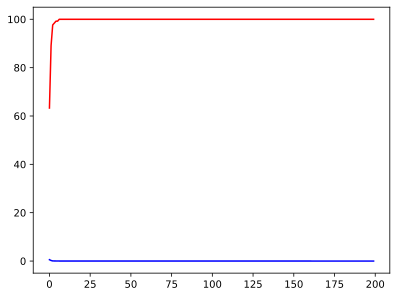

In [15]:
plt.plot(accuracies, 'r-')
plt.plot(losses, 'b-')

In [16]:
test_accuracy

94.11764526367188